<a href="https://colab.research.google.com/github/eteh1/House-Price-Prediction/blob/main/House_Price_Prediction_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<ipython-input-1-f9f329d44bcc>:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Location'] = location_numeric  # Add numerical location feature


Mean Absolute Error: 8310.156623214278
Mean Squared Error: 107923125.99564034
R^2 Score: 0.9990158554213172


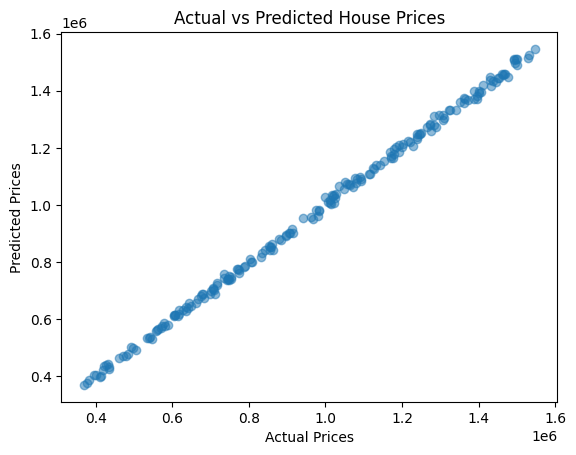

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Generate synthetic dataset
np.random.seed(42)
n_samples = 1000

area = np.random.randint(1000, 5000, n_samples)  # Square footage
bedrooms = np.random.randint(1, 6, n_samples)    # Number of bedrooms
location = np.random.choice(['Urban', 'Suburban', 'Rural'], n_samples)  # Location category

# Assign numerical values to location
location_dict = {'Urban': 3, 'Suburban': 2, 'Rural': 1}
location_numeric = np.array([location_dict[l] for l in location])

# Generate house prices based on area, bedrooms, and location (with some noise)
price = (area * 300) + (bedrooms * 5000) + (location_numeric * 20000) + np.random.randint(-10000, 10000, n_samples)

# Create DataFrame
data = pd.DataFrame({'Area': area, 'Bedrooms': bedrooms, 'Location': location, 'Price': price})

# Convert categorical features
X = data[['Area', 'Bedrooms']]
X['Location'] = location_numeric  # Add numerical location feature
y = data['Price']

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a Random Forest Regressor model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Absolute Error: {mae}')
print(f'Mean Squared Error: {mse}')
print(f'R^2 Score: {r2}')

# Visualization of Actual vs Predicted Prices
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted House Prices')
plt.show()